# Performance Comparison of Dimension Reduction Implementations

Different dimension reduction techniques have very different computational costs. The algorithm matters, but so do implementation details such as nearest-neighbor search, numerical solvers, and parallel execution. The shape of the input data matters as well. In this notebook we will compare current maintained implementations on increasingly large subsets of MNIST and see how their runtimes scale.

This is intended as a practical implementation comparison rather than a claim that every method solves exactly the same optimization problem. Each estimator uses its current defaults except where parameters are set explicitly for reproducibility, parallelism, or to select the new UMAP layout path.

## Benchmark setup

The comparison includes PCA and the manifold-learning implementations provided by scikit-learn, together with UMAP and [openTSNE](https://opentsne.readthedocs.io/). The old version of this benchmark used MulticoreTSNE. That project has not published a release since 2019 and does not build cleanly with current Python and CMake versions, so openTSNE is now the maintained external t-SNE implementation in the comparison.

All algorithms are allowed to use every available thread. UMAP is configured with recursive initialization and the Adam optimizer, and is warmed up before measurement so Numba compilation is not included in its timings. The input is converted once to a C-contiguous `float32` array. A fixed permutation produces nested subsets: every smaller benchmark is a prefix of the larger ones.

The methods with quadratic memory or runtime are stopped at smaller sizes. MDS is measured through 1,000 samples; spectral embedding, Isomap, and locally linear embedding through 5,000. PCA, UMAP, openTSNE, and scikit-learn t-SNE are measured through all 70,000 MNIST samples. Small measurements are repeated to expose timing variation, while the most expensive large runs are performed once.

In [1]:
import contextlib
import gc
import io
import os
import platform
import struct
import subprocess
import tarfile
from pathlib import Path
from time import perf_counter
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numba
import numpy as np
import openTSNE
import pandas as pd
import pynndescent
import scipy
import seaborn as sns
import sklearn
from openTSNE import TSNE as OpenTSNE
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import (
    Isomap,
    LocallyLinearEmbedding,
    MDS,
    SpectralEmbedding,
    TSNE,
)
from threadpoolctl import threadpool_info
import umap

sns.set_theme(context="notebook", style="whitegrid")

For a performance comparison it is important to record the software and hardware context. In particular, the version of an implementation can matter as much as the algorithm name. The following is the environment used to produce the results on this page.

In [2]:
versions = pd.Series(
    {
        "Python": platform.python_version(),
        "NumPy": np.__version__,
        "SciPy": scipy.__version__,
        "scikit-learn": sklearn.__version__,
        "Numba": numba.__version__,
        "PyNNDescent": pynndescent.__version__,
        "openTSNE": openTSNE.__version__,
        "umap-learn": umap.__version__,
    },
    name="version",
)
print(versions.to_string())
print(f"Logical CPUs: {os.cpu_count()}")
print(f"Numba threads: {numba.get_num_threads()}")
print("Native thread pools:")
for pool in threadpool_info():
    print(
        f"  {pool['internal_api']}: {pool['num_threads']} threads "
        f"({pool.get('prefix', 'unknown')})"
    )

Python          3.12.3
NumPy            2.5.2
SciPy           1.18.0
scikit-learn     1.9.0
Numba           0.67.0
PyNNDescent      0.6.0
openTSNE         1.0.4
umap-learn       0.6.0
Logical CPUs: 64
Numba threads: 64
Native thread pools:
  openblas: 64 threads (libscipy_openblas)
  openblas: 64 threads (libscipy_openblas)
  openmp: 64 threads (libgomp)
  openmp: 64 threads (libgomp)


## Loading MNIST

MNIST remains a useful common benchmark for manifold-learning implementations: it has 70,000 samples, 784 input dimensions, and enough structure that the resulting embeddings can also be inspected visually. We convert the data to the representation used by the benchmark and apply one deterministic permutation.

In [3]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
data = np.ascontiguousarray(mnist.data, dtype=np.float32)
labels = np.asarray(mnist.target, dtype=np.int32)

permutation = np.random.RandomState(42).permutation(data.shape[0])
data = np.ascontiguousarray(data[permutation])
labels = labels[permutation]

data.shape, data.dtype, data.flags.c_contiguous

((70000, 784), dtype('float32'), True)

## Estimator configurations

Every timing constructs a fresh estimator. `n_jobs=-1` is used wherever the implementation exposes it, so no artificial thread cap is imposed. The t-SNE implementations retain their current iteration defaults; these defaults are not identical, which is one reason the results should be read as implementation timings rather than a controlled comparison of optimizer kernels. MDS uses one random initialization, matching its current `n_init=1` default while making the initialization choice explicit.

In [4]:
def make_pca():
    return PCA(n_components=2, random_state=42)


def make_umap():
    return umap.UMAP(
        n_components=2,
        init="recursive",
        optimizer="adam",
        compatibility_layout=False,
        n_jobs=-1,
        random_state=42,
    )


def make_open_tsne():
    return OpenTSNE(n_components=2, n_jobs=-1, random_state=42)


def make_sklearn_tsne():
    return TSNE(n_components=2, n_jobs=-1, random_state=42)


def make_lle():
    return LocallyLinearEmbedding(
        n_components=2, n_jobs=-1, random_state=42
    )


def make_spectral():
    return SpectralEmbedding(n_components=2, n_jobs=-1, random_state=42)


def make_isomap():
    return Isomap(n_components=2, n_jobs=-1)


def make_mds():
    return MDS(
        n_components=2,
        n_init=1,
        init="random",
        n_jobs=-1,
        random_state=42,
    )


benchmark_specs = {
    "PCA": {"factory": make_pca, "max_size": 70000},
    "UMAP": {"factory": make_umap, "max_size": 70000},
    "openTSNE": {"factory": make_open_tsne, "max_size": 70000},
    "scikit-learn t-SNE": {
        "factory": make_sklearn_tsne,
        "max_size": 70000,
    },
    "Locally linear embedding": {"factory": make_lle, "max_size": 5000},
    "Spectral embedding": {
        "factory": make_spectral,
        "max_size": 5000,
    },
    "Isomap": {"factory": make_isomap, "max_size": 5000},
    "MDS": {"factory": make_mds, "max_size": 1000},
}

sizes = [500, 1000, 2500, 5000, 10000, 25000, 50000, 70000]
repeats = {500: 3, 1000: 3, 2500: 2, 5000: 2, 10000: 1, 25000: 1, 50000: 1, 70000: 1}

## Warming up UMAP

UMAP uses Numba to compile performance-critical functions. It has separate optimizer kernels for small and large inputs, so we run the exact UMAP configuration once on both a 500-row and a 5,000-row subset before starting the timer. This exercises the compiled paths used by the measured fits, so the UMAP results below do not include one-time JIT compilation.

In [5]:
%%capture
make_umap().fit_transform(np.ascontiguousarray(data[:500]))
make_umap().fit_transform(np.ascontiguousarray(data[:5000]))

## Measuring scaling by dataset size

The helper below times only `fit_transform` (or openTSNE's equivalent `fit` operation). It verifies that every result is finite, retains the full-MNIST embeddings for visual inspection, and releases estimator state between runs. Progress is printed as the notebook executes because the complete benchmark takes several minutes.

In [6]:
full_embeddings = {}
records = []


def fit_embedding(name, estimator, sample):
    if name == "openTSNE":
        return np.asarray(estimator.fit(sample))
    if name == "UMAP":
        with contextlib.redirect_stdout(io.StringIO()):
            return estimator.fit_transform(sample)
    return estimator.fit_transform(sample)


for name, spec in benchmark_specs.items():
    for size in sizes:
        if size > spec["max_size"]:
            continue
        sample = np.ascontiguousarray(data[:size])
        for run in range(repeats[size]):
            estimator = spec["factory"]()
            start = perf_counter()
            embedding = fit_embedding(name, estimator, sample)
            elapsed = perf_counter() - start
            if not np.isfinite(embedding).all():
                raise RuntimeError(f"{name} returned a non-finite embedding")
            records.append(
                {
                    "algorithm": name,
                    "samples": size,
                    "run": run + 1,
                    "seconds": elapsed,
                }
            )
            if size == data.shape[0] and run == 0:
                full_embeddings[name] = np.asarray(embedding).copy()
            print(
                f"{name:26s} {size:6d} samples, run {run + 1}: "
                f"{elapsed:8.3f} s"
            )
            del estimator, embedding
            gc.collect()

results = pd.DataFrame.from_records(records)

PCA                           500 samples, run 1:    0.005 s
PCA                           500 samples, run 2:    0.004 s
PCA                           500 samples, run 3:    0.003 s


PCA                          1000 samples, run 1:    0.006 s
PCA                          1000 samples, run 2:    0.005 s
PCA                          1000 samples, run 3:    0.005 s


PCA                          2500 samples, run 1:    0.077 s
PCA                          2500 samples, run 2:    0.014 s


PCA                          5000 samples, run 1:    0.032 s
PCA                          5000 samples, run 2:    0.031 s


PCA                         10000 samples, run 1:    0.251 s


...

MDS                           500 samples, run 2:    1.837 s


MDS                           500 samples, run 3:    1.810 s


MDS                          1000 samples, run 1:    4.814 s


MDS                          1000 samples, run 2:    4.872 s


MDS                          1000 samples, run 3:    4.996 s


The table reports the median time at each measured size. At sizes with repeated runs, the minimum and maximum show the observed spread. A single large run should be treated as a representative measurement on this machine rather than a precise estimate of expected runtime elsewhere.

In [7]:
summary = (
    results.groupby(["algorithm", "samples"])["seconds"]
    .agg(median="median", minimum="min", maximum="max", runs="size")
    .reset_index()
)
summary

,algorithm,samples,median,minimum,maximum,runs
0,Isomap,500,0.051414,0.051231,0.094258,3
1,Isomap,1000,0.147952,0.146672,0.209341,3
2,Isomap,2500,0.863099,0.859302,0.866895,2
3,Isomap,5000,3.671477,3.657586,3.685367,2
4,Locally linear embedding,500,0.053908,0.053482,0.054242,3
5,Locally linear embedding,1000,0.112078,0.112007,0.112769,3
6,Locally linear embedding,2500,0.378100,0.376638,0.379563,2
7,Locally linear embedding,5000,1.626079,1.612987,1.639171,2
8,MDS,500,1.837274,1.810016,2.083045,3
9,MDS,1000,4.872294,4.814347,4.995596,3


## Comparing scaling

The first plot focuses on the range where all maintained implementations can be compared. The second follows the four implementations that complete the full MNIST dataset. Logarithmic axes make differences in scaling easier to see.

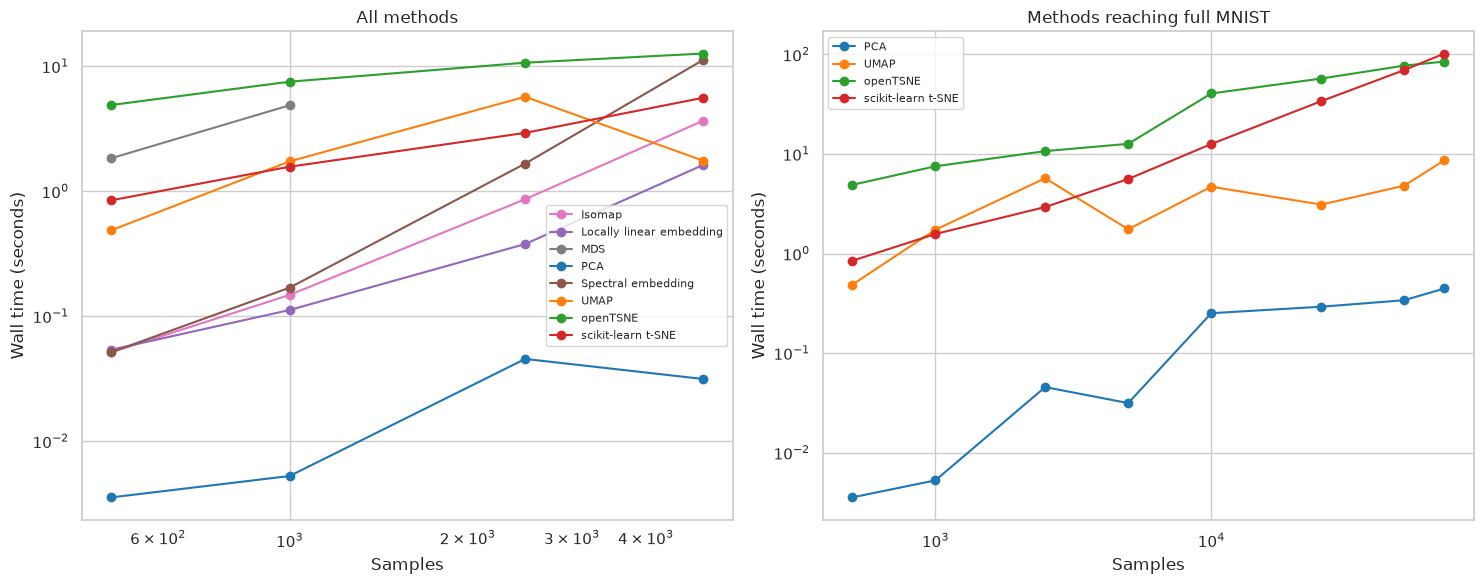

In [8]:
palette = dict(
    zip(benchmark_specs, sns.color_palette("tab10", len(benchmark_specs)))
)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

small = summary[summary["samples"] <= 5000]
for name, group in small.groupby("algorithm", sort=False):
    axes[0].plot(
        group["samples"],
        group["median"],
        marker="o",
        label=name,
        color=palette[name],
    )
axes[0].set(title="All methods", xlabel="Samples", ylabel="Wall time (seconds)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)

scalable_names = ["PCA", "UMAP", "openTSNE", "scikit-learn t-SNE"]
scalable = summary[summary["algorithm"].isin(scalable_names)]
for name, group in scalable.groupby("algorithm", sort=False):
    axes[1].plot(
        group["samples"],
        group["median"],
        marker="o",
        label=name,
        color=palette[name],
    )
axes[1].set(
    title="Methods reaching full MNIST",
    xlabel="Samples",
    ylabel="Wall time (seconds)",
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

The small-data plot demonstrates why no single benchmark size tells the whole story. Methods with dense pairwise computations can be quite reasonable for hundreds of samples and then rapidly become impractical. PCA remains the least expensive option, but it is a linear projection and is solving a different problem from the manifold methods.

UMAP's curve is not monotonic around the small-to-medium transition. UMAP selects different nearest-neighbor and layout implementations according to dataset size; crossing one of those implementation boundaries can make a somewhat larger dataset faster. This is another reason to benchmark the sizes relevant to an application instead of fitting a single smooth complexity curve through all measurements.

On the larger subsets, current scikit-learn t-SNE is much more competitive than the historical benchmark suggested, and openTSNE remains a strong maintained t-SNE implementation. UMAP nevertheless has substantially lower runtime on this dataset and hardware. The exact ratios are machine- and version-dependent; the shapes of the scaling curves are more informative than any single number.

## Full-MNIST results

The full-data measurements provide a concrete summary for this machine. All methods shown here processed the same 70,000-row C-contiguous `float32` matrix and were allowed to use all available threads.

In [9]:
full_summary = (
    summary[summary["samples"] == data.shape[0]]
    .set_index("algorithm")
    .loc[["PCA", "UMAP", "openTSNE", "scikit-learn t-SNE"]]
)
full_summary[["median", "runs"]]

,median,runs
algorithm,,
PCA,0.445202,1
UMAP,8.642001,1
openTSNE,84.773057,1
scikit-learn t-SNE,102.094551,1


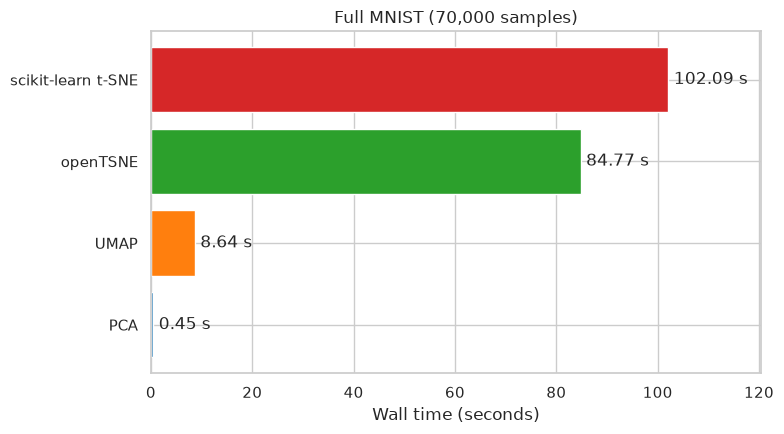

In [10]:
fig, axis = plt.subplots(figsize=(8, 4.5))
bars = axis.barh(
    full_summary.index,
    full_summary["median"],
    color=[palette[name] for name in full_summary.index],
)
axis.set(xlabel="Wall time (seconds)", title="Full MNIST (70,000 samples)")
axis.bar_label(bars, fmt="%.2f s", padding=4)
axis.set_xlim(0, full_summary["median"].max() * 1.18)
plt.tight_layout()
plt.show()

Runtime is only one part of a dimension reduction comparison. To make sure the successful full-data runs also produced recognizable embeddings, we can inspect the four results side by side. These plots are not a formal quality benchmark; each method has parameters that can change the result and runtime.

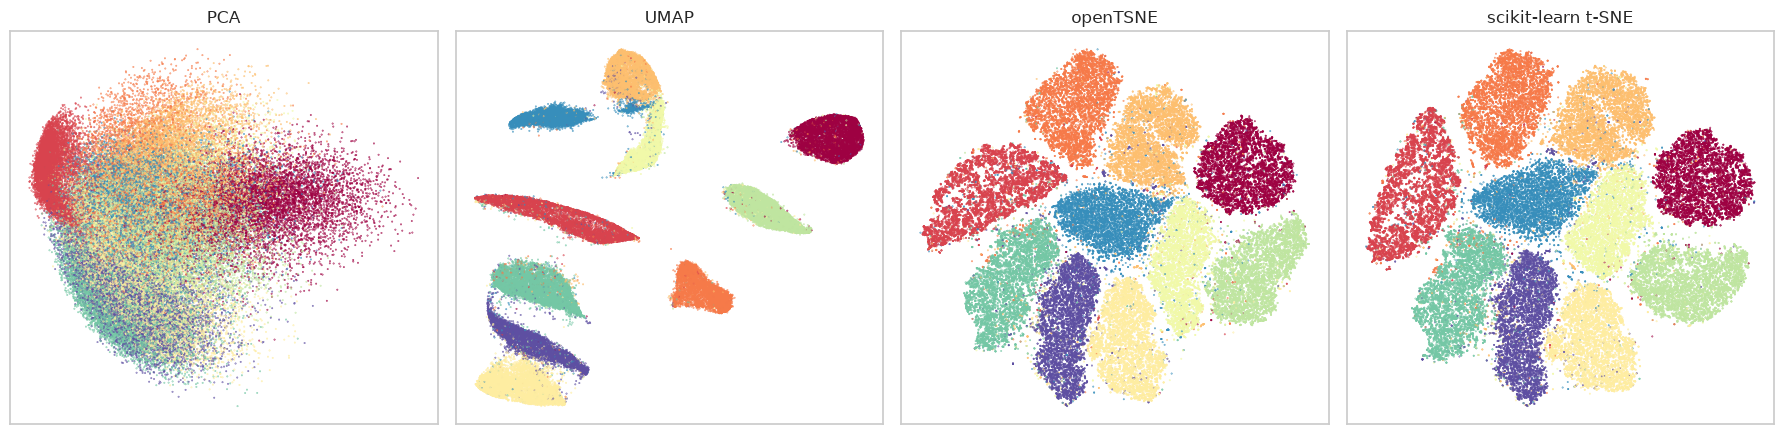

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for name, axis in zip(
    ["PCA", "UMAP", "openTSNE", "scikit-learn t-SNE"], axes
):
    embedding = full_embeddings[name]
    axis.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="Spectral",
        s=0.12,
        rasterized=True,
    )
    axis.set_title(name)
    axis.set_xticks([])
    axis.set_yticks([])
plt.tight_layout()
plt.show()

## Scaling beyond MNIST with InfiMNIST

MNIST ends at 70,000 samples, so it cannot show how the scalable methods behave farther out. [InfiMNIST](https://leon.bottou.org/projects/infimnist) provides a deterministic supply of transformed MNIST digits. Each pattern still has 784 byte-valued features, but indices at and above 70,000 apply pseudorandom deformations to the original training images. This lets us increase sample count without changing the data domain or dimensionality.

The InfiMNIST 1.3 archive is distributed under the GNU Lesser General Public License version 3. The notebook downloads and builds it in `~/.cache/umap-benchmarks`; neither the 350 MB source/data archive nor generated samples are stored in this repository. A C compiler and `make` are required when populating the cache for the first time. The archive checksum is verified before extraction.

In [12]:
INFIMNIST_VERSION = "1.3"
INFIMNIST_URL = "https://leon.bottou.org/_media/projects/infimnist.tar.gz"
INFIMNIST_SHA256 = "bff89ae6a80bd7be5de0cc67eaac0db7bb1945287d27c216a18f9924069dc1bb"
INFIMNIST_SAMPLES = 500_000
INFIMNIST_FIRST_INDEX = 70_000

cache_root = Path.home() / ".cache" / "umap-benchmarks"
archive_path = cache_root / "infimnist.tar.gz"
source_dir = cache_root / "infimnist"
executable = source_dir / "infimnist"
generated_dir = source_dir / "generated"
images_path = generated_dir / "infimnist-500k-images-idx3-ubyte"
labels_path = generated_dir / "infimnist-500k-labels-idx1-ubyte"
cache_root.mkdir(parents=True, exist_ok=True)


def sha256(path):
    import hashlib

    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


if not archive_path.exists():
    print(f"Downloading InfiMNIST {INFIMNIST_VERSION} (~350 MB)...")
    urlretrieve(INFIMNIST_URL, archive_path)
if sha256(archive_path) != INFIMNIST_SHA256:
    raise RuntimeError("The cached InfiMNIST archive has an unexpected checksum")

if not source_dir.exists():
    with tarfile.open(archive_path, "r:gz") as archive:
        archive.extractall(cache_root, filter="data")
if not executable.exists():
    subprocess.run(["make", "-C", str(source_dir)], check=True)


def idx_header(path, fields):
    with path.open("rb") as stream:
        return struct.unpack(">" + "I" * fields, stream.read(4 * fields))


def infimnist_cache_is_valid():
    return (
        images_path.exists()
        and labels_path.exists()
        and idx_header(images_path, 4) == (2051, INFIMNIST_SAMPLES, 28, 28)
        and idx_header(labels_path, 2) == (2049, INFIMNIST_SAMPLES)
    )


if not infimnist_cache_is_valid():
    generated_dir.mkdir(exist_ok=True)
    last_index = INFIMNIST_FIRST_INDEX + INFIMNIST_SAMPLES - 1
    temporary_images = images_path.with_suffix(".tmp")
    temporary_labels = labels_path.with_suffix(".tmp")
    print(f"Generating {INFIMNIST_SAMPLES:,} deterministic InfiMNIST samples...")
    with temporary_images.open("wb") as stream:
        subprocess.run(
            [
                str(executable),
                "-d",
                str(source_dir / "data"),
                "patterns",
                str(INFIMNIST_FIRST_INDEX),
                str(last_index),
            ],
            stdout=stream,
            check=True,
        )
    with temporary_labels.open("wb") as stream:
        subprocess.run(
            [
                str(executable),
                "-d",
                str(source_dir / "data"),
                "labels",
                str(INFIMNIST_FIRST_INDEX),
                str(last_index),
            ],
            stdout=stream,
            check=True,
        )
    temporary_images.replace(images_path)
    temporary_labels.replace(labels_path)

if not infimnist_cache_is_valid():
    raise RuntimeError("Generated InfiMNIST IDX files failed validation")

infimnist_images = np.memmap(
    images_path,
    mode="r",
    dtype=np.uint8,
    offset=16,
    shape=(INFIMNIST_SAMPLES, 784),
)
infimnist_labels = np.memmap(
    labels_path,
    mode="r",
    dtype=np.uint8,
    offset=8,
    shape=(INFIMNIST_SAMPLES,),
)

print(f"InfiMNIST {INFIMNIST_VERSION}: {infimnist_images.shape}, {infimnist_images.dtype}")
display_path = Path("~") / images_path.relative_to(Path.home())
print(f"Image cache: {display_path} ({images_path.stat().st_size / 2**20:.1f} MiB)")

InfiMNIST 1.3: (500000, 784), uint8
Image cache: ~/.cache/umap-benchmarks/infimnist/generated/infimnist-500k-images-idx3-ubyte (373.8 MiB)


The generated image file is memory-mapped as `uint8`, keeping the persistent cache compact. For each measurement the requested prefix is converted to a C-contiguous `float32` array before the timer starts, matching the data representation used in the MNIST benchmark.

PCA, UMAP, and openTSNE are measured at 100,000, 250,000, and 500,000 samples. Current scikit-learn t-SNE completes 100,000 samples, but a separate 250,000-sample probe did not finish after twenty minutes on this machine, so its extended curve is deliberately capped at 100,000 rather than turning notebook regeneration into an impractical workload. Each high-scale point is measured once.

In [13]:
large_specs = {
    "PCA": {"factory": make_pca, "max_size": 500_000},
    "UMAP": {"factory": make_umap, "max_size": 500_000},
    "openTSNE": {"factory": make_open_tsne, "max_size": 500_000},
    "scikit-learn t-SNE": {"factory": make_sklearn_tsne, "max_size": 100_000},
}
large_sizes = [100_000, 250_000, 500_000]
large_records = []
large_embeddings = {}

for name, spec in large_specs.items():
    for size in large_sizes:
        if size > spec["max_size"]:
            continue
        sample = np.ascontiguousarray(infimnist_images[:size], dtype=np.float32)
        estimator = spec["factory"]()
        start = perf_counter()
        embedding = fit_embedding(name, estimator, sample)
        elapsed = perf_counter() - start
        if not np.isfinite(embedding).all():
            raise RuntimeError(f"{name} returned a non-finite InfiMNIST embedding")
        large_records.append(
            {"algorithm": name, "samples": size, "seconds": elapsed}
        )
        if size == 500_000:
            large_embeddings[name] = np.asarray(embedding).copy()
        print(f"{name:22s} {size:7,d} samples: {elapsed:8.3f} s")
        del sample, estimator, embedding
        gc.collect()

large_results = pd.DataFrame.from_records(large_records)
large_results

PCA                    100,000 samples:    0.701 s


PCA                    250,000 samples:    1.450 s


PCA                    500,000 samples:    2.808 s


UMAP                   100,000 samples:   11.310 s


UMAP                   250,000 samples:   36.502 s


...

openTSNE               100,000 samples:  108.110 s


openTSNE               250,000 samples:  192.118 s


openTSNE               500,000 samples:  336.963 s


scikit-learn t-SNE     100,000 samples:  155.445 s


,algorithm,samples,seconds
0,PCA,100000,0.700818
1,PCA,250000,1.449518
2,PCA,500000,2.807720
3,UMAP,100000,11.310292
4,UMAP,250000,36.502425
5,UMAP,500000,60.168777
6,openTSNE,100000,108.110346
7,openTSNE,250000,192.117548
8,openTSNE,500000,336.962846
9,scikit-learn t-SNE,100000,155.444559


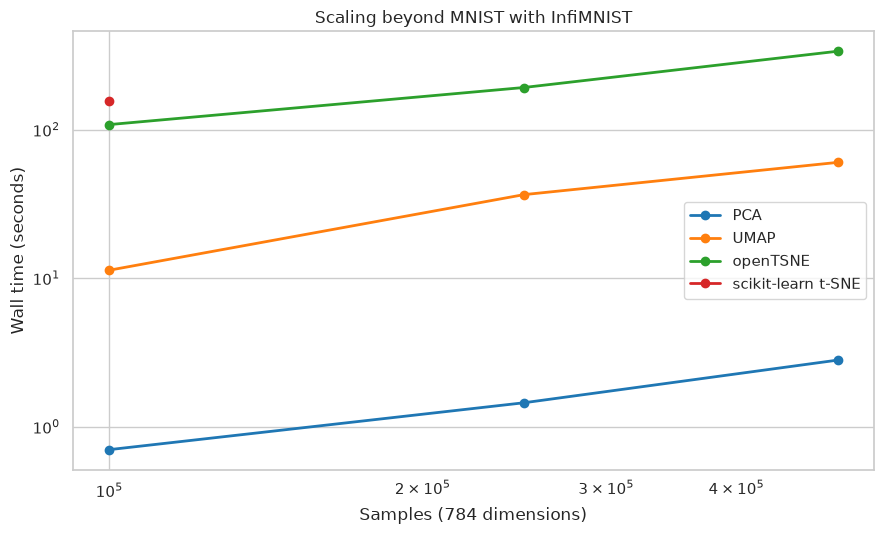

In [14]:
fig, axis = plt.subplots(figsize=(9, 5.5))
for name, group in large_results.groupby("algorithm", sort=False):
    axis.plot(
        group["samples"],
        group["seconds"],
        marker="o",
        linewidth=2,
        label=name,
        color=palette[name],
    )
axis.set(
    title="Scaling beyond MNIST with InfiMNIST",
    xlabel="Samples (784 dimensions)",
    ylabel="Wall time (seconds)",
)
axis.set_xscale("log")
axis.set_yscale("log")
axis.legend()
plt.tight_layout()
plt.show()

The larger dataset makes the scaling differences much clearer. UMAP takes about a minute at 500,000 samples on this machine, while openTSNE takes several minutes. PCA is faster still, with the same caveat as before that it is a linear method solving a different problem. The scikit-learn t-SNE curve stops at 100,000 because larger runs were not practical under this notebook's regeneration budget.

As with the MNIST results, these values describe this package set and machine. InfiMNIST makes it straightforward to extend the experiment to one million samples or more when a longer benchmark budget is appropriate.

## Reproducing the benchmark

The exact package versions are recorded in `notebooks/benchmarking-requirements.txt`. From the repository root the environment can be recreated with:

```bash
uv venv --python 3.12 .benchmark-latest-venv
uv pip install --python .benchmark-latest-venv/bin/python -e . \
    -r notebooks/benchmarking-requirements.txt
```

The notebook can then be executed and converted into the published page with:

```bash
PATH="$PWD/.benchmark-latest-venv/bin:$PATH" \
    .benchmark-latest-venv/bin/jupyter nbconvert --to notebook --execute \
    --inplace notebooks/benchmarking.ipynb \
    --ExecutePreprocessor.timeout=3600 --ExecutePreprocessor.kernel_name=python3
PATH="$PWD/.benchmark-latest-venv/bin:$PATH" \
    .benchmark-latest-venv/bin/jupyter nbconvert --to rst \
    notebooks/benchmarking.ipynb --output benchmarking --output-dir doc
sed -i 's/[[:space:]]\+$//' doc/benchmarking.rst
```

Performance results should always be regenerated after changing package versions, thread limits, estimator defaults, or the benchmark machine.